#### Imports

In [1]:
from  Rolling_Intrinsic_QH import load_fake_data, run_optimization_quarterhours_repositioning, get_net_trades, load_real_data, get_average_prices
import os
import pandas as pd
from loguru import logger
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
logger.remove()
df = pd.read_parquet("../../id_prices.parquet")

c:\Users\UnmuBhar\Documents\Intraday Research\POCs\Rolling-Intrinsic-BESS-Intraday-Trading\Code\Rolling Intrinsic


### EDA

Look at the price development of one single ID product as you approach the delivery time. 

<Axes: title={'center': 'Price Development of 1 MWh at 2025-02-01 01:00:00'}, xlabel='Time of Executed Trade', ylabel='€/MWh'>

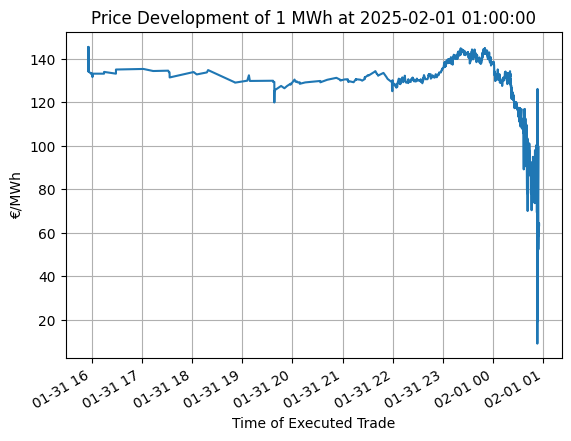

In [2]:
product = "2025-02-01 01:00:00"
df[df.deliverystart==product].loc[:,"price"].plot(title=f"Price Development of 1 MWh at {product}",
                                                                      ylabel="€/MWh",
                                                                      xlabel="Time of Executed Trade",
                                                                      grid=True)

The chart below shows trading activity of many different products as they get closer to delivery time

In [37]:
df_temp = df.loc[exec_time_range,:].copy()
start_delivery = df_temp.index[-1].normalize()
end_delivery = start_delivery.replace(hour=23,minute=45)

filter = (df_temp.deliverystart >= start_delivery) & (df_temp.deliverystart <= end_delivery)
df_temp["buckets"] = df_temp.index.ceil("5min")
df_temp = df_temp[filter]

counts = df_temp.groupby(["buckets","deliverystart"]).size().reset_index(name="n_trades")
heatmap = counts.pivot(columns="buckets",index="deliverystart",values="n_trades").fillna(0)
heatmap.index = heatmap.index.strftime("%H:%M")
heatmap.columns = heatmap.columns.strftime("%D %H:%M")


Text(0.5, 25.722222222222214, 'Execution Time of trades')

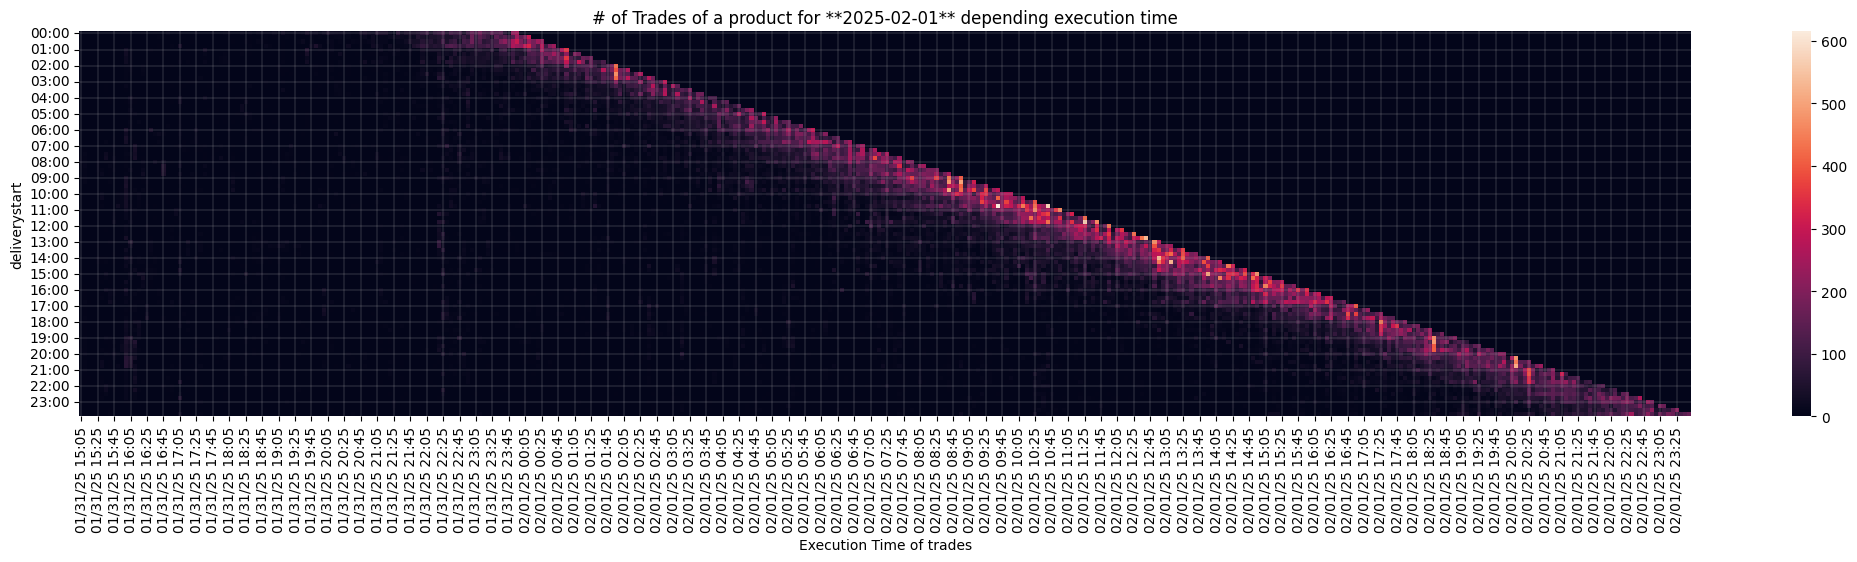

In [38]:
_,ax = plt.subplots(1,1,figsize=(26,5))
ax.set_title(f"# of Trades of a product for **{start_delivery.date()}** depending execution time")
ax.grid(True,linewidth=0.2)

sns.heatmap(heatmap,ax = ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set_xlabel("Execution Time of trades")

So far we have only looked at market data. The next step is to consider how the plots from BESS trading activities should look!

### Task 1 : Visualize trades by BESS and Do it with an interactive chart in streamlit!

Desired goals of streamlit dashboard:
- [ _ ] Show individual days revenue
- [ _ ] Show cummulative revenue of chosen year
- [ _ ] On the side show the Bess parameters
- [ _ ] Enable adjustment of simulation parameters
- [ _ ] Enable adjustment of BESS parameters
- [ _ ] Enable Running of Simulation!

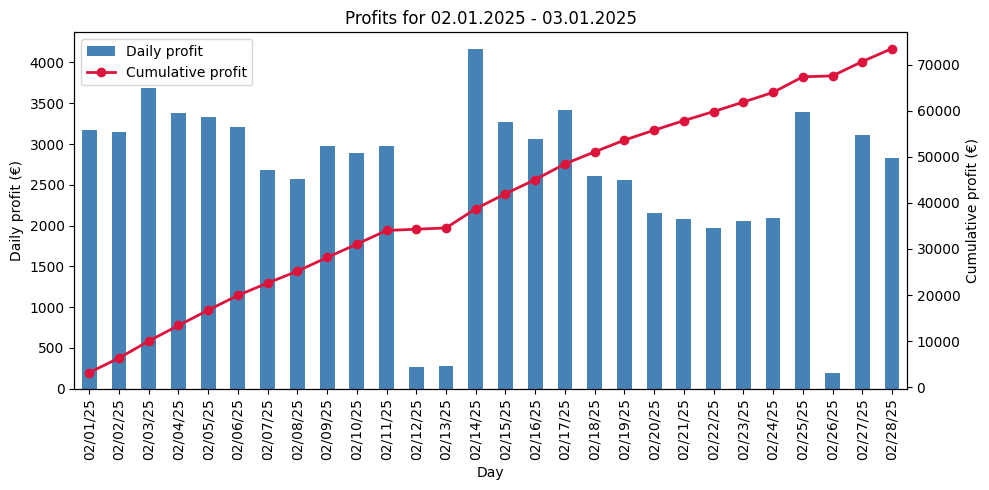

In [103]:
filter = slice("02.01.2025","03.01.2025")
initial_results = pd.read_csv("../../output/quarterhourly/bs15cr1rto0.85mc60.833333333333336mt5/profit.csv",
                              index_col="day",
                              parse_dates=True
                              )
initial_results.index = initial_results.index.strftime("%D")
initial_results = initial_results[filter]
# ── build the figure ───────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

# 1️⃣ daily profit – bar chart on the left y-axis
initial_results["profit"].plot(
    kind="bar",
    color="steelblue",
    ax=ax1,
    label="Daily profit",
)
ax1.set_ylabel("Daily profit (€)")

# 2️⃣ cumulative profit – line on the right y-axis
ax2 = ax1.twinx()                                 # second y-axis
initial_results["profit"].cumsum().plot(
    ax=ax2,
    color="crimson",
    marker="o",
    linewidth=2,
    label="Cumulative profit",
)
ax2.set_ylabel("Cumulative profit (€)")
# cosmetics
ax1.set_xlabel("Day")
ax1.tick_params(axis="x")
# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title(f"Profits for {filter.start} - {filter.stop}")
plt.tight_layout()

#### Task 1c : Use only February as an example, and enable rerunning of simulation just for february